In [3]:
from utils import * 
import subprocess
import json
from Bio.Align import PairwiseAligner 
import itertools
import requests

%load_ext autoreload 
%autoreload 2

ALPHAFOLD_DIR = '../data/genes/alphafold/'
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/'
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'
COLABFOLD_OUTPUT_DIR = '../data/genes/colabfold/'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.cluster_id == 7].copy()
genes_df['alphafold_id'] = genes_df.genome_id.apply(lambda genome_id : f'{genome_id}_cluster_7_1mer')

FASTAFile.from_df(genes_df).write('../data/genes/cluster_7.faa')
# subprocess.run('muscle -align ../data/genes/cluster_7.faa -output ../data/genes/cluster_7.afa', shell=True, check=True)
msa = MSAFile.from_file('../data/genes/cluster_7.afa')

for row in genes_df.itertuples():
    print(f'{row.Index}')

print('\nMinimum cluster_7 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_7 gene length:', genes_df.seq.apply(len).max())

orfm.bz_0.1_82
orfm.bz_1.1_43
orfm.bz_2.1_117
orfm.bz_3.1_142
orfm.bz_5.1_26
orfm.bz_7.1_68
orfm.bz_8.1_106
orfm.bz_9.1_152
orfm.bz_10.1_110
orfm.bz_11.1_147

Minimum cluster_7 gene length: 207
Maximum cluster_7 gene length: 311


In [5]:
tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')
genes_df['num_tmhs'] = genes_df.index.map(tmhmm_file.get_num_tmhs())
    
for row in genes_df.itertuples():
    print(f'Number TMHs in {row.genome_id} cluster_1 protein:', row.num_tmhs)

Number TMHs in bz_0 cluster_1 protein: 0
Number TMHs in bz_1 cluster_1 protein: 0
Number TMHs in bz_2 cluster_1 protein: 0
Number TMHs in bz_3 cluster_1 protein: 0
Number TMHs in bz_5 cluster_1 protein: 0
Number TMHs in bz_7 cluster_1 protein: 0
Number TMHs in bz_8 cluster_1 protein: 0
Number TMHs in bz_9 cluster_1 protein: 0
Number TMHs in bz_10 cluster_1 protein: 0
Number TMHs in bz_11 cluster_1 protein: 0


In [6]:
outputs = [AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, gene_id)) for gene_id in genes_df.index]
# outputs = [ColabFoldOutput(os.path.join(COLABFOLD_OUTPUT_DIR, get_genome_id(gene_id), gene_id)) for gene_id in genes_df.index]
# Substantial improvement with the custom MSAFiles! The improvement in pTM is likely due to the addition of the custom MSAFiles, not differences between the 
# AlphaFold2 and AlphaFold3 architectures, see Peng et. al. 2025 (https://pmc.ncbi.nlm.nih.gov/articles/PMC12661943/)

for output in outputs:
    print(output.name, output.get_ptms(best_model=True))

orfm.bz_0.1_82 0.57
orfm.bz_1.1_43 0.61
orfm.bz_2.1_117 0.59
orfm.bz_3.1_142 0.59
orfm.bz_5.1_26 0.6
orfm.bz_7.1_68 0.59
orfm.bz_8.1_106 0.57
orfm.bz_9.1_152 0.53
orfm.bz_10.1_110 0.53
orfm.bz_11.1_147 0.56


In [ ]:
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/level_1_conserved_clusters*')])
foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin(genes_df.index)].copy()

target_header_map = dict()
target_header_map['A0A8S5LVD6'] = 'Zinc ribbon domain protein'
target_header_map['A0A7L7SSE5'] = 'Uncharacterized protein' 
target_header_map['A0A8S5RLS8'] = 'Uncharacterized protein' 

foldseek_search_df['target_header'] = foldseek_search_df.target_header.apply(lambda header : target_header_map.get(header, header))


In [ ]:
filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.7
# filters['low_query_coverage'] = foldseek_search_df.query_coverage < 0.5
filters['short_alignment'] = foldseek_search_df.alignment_length < 100
filters['synthetic'] = foldseek_search_df.target_header.str.contains('De novo design')

foldseek_search_df = apply_filters(filters, foldseek_search_df)

print('Leftmost alignment start:', foldseek_search_df.query_start.min())
print('Leftmost alignment end:', foldseek_search_df.query_end.min())


# Looking at a ~350-aa Dpo4-like protein, the first ~230 aa are the actual polymerase core, while the C-terminal ~100 aa are the LF/PAD. 
# Based on this, it seems as though the relevant structural similarity is to the dsDNA binding component. 

# Zinc ribbon domain protein 
categories = dict()

categories['ImuB'] = foldseek_search_df.target_header.str.contains('ImuB', case=False) 
# "ImuB, which is predicted to enable mutasome function via its interaction with the beta clamp, is a catalytically inactive Y-family DNA polymerase."
# The C-terminal half of cluster_7 aligns to residues 230-350 of ImuB (the full protein is about 500 residues). This is apparently part of the
# Y-family polymerase-like architecture, including the little-finger (LF) domain characteristic of Y-family polymerases.
# https://pmc.ncbi.nlm.nih.gov/articles/PMC2919956
# ImuB has a beta-clamp binding motif (it is not the beta-clamp itself)

categories['little finger domain-containing protein'] = foldseek_search_df.target_header.str.contains('little finger', case=False) 
# A key domain in type Y DNA polymerases, which are a family of specialized translesion synthesis (TLS) polymerases that can replicate across damaged DNA.
# It also called the polymerase-associated domain (PAD). The LF/PAD domain primarily contacts the duplex portion of the primer–template DNA

categories['MsDpo4'] = foldseek_search_df.target_header.str.contains('MsDpo4', case=False) 
# This is an example of a Y-family DNA polymerase. Specifically, it is from Methanosarcina.

categories['DinB'] = foldseek_search_df.target_header.str.contains('DNA polymerase IV|dinB|DNA polymerase-4', case=False) 
# DNA polymerase IV (Pol IV) is the bacterial Y-family translesion synthesis polymerase, usually encoded by dinB.

categories['DNA polymerase Y'] = foldseek_search_df.target_header.str.contains('Y-family DNA polymerase|DNA polymerase Y', case=False) 

categories['DNA polymerase V'] = foldseek_search_df.target_header.str.contains('DNA polymerase V|UmuC', case=False)
# DNA polymerase V (Pol V) is another bacterial Y-family DNA polymerase. It is made up of UmuC and UmuD, and the UmuC subunit is the catalytic Y-family polymerase.

categories['DNA polymerase'] = foldseek_search_df.target_header.str.contains('polymerase', case=False)

categories['UvrA'] = foldseek_search_df.target_header.str.contains('Excinuclease ABC subunit A|UvrA') 
# The UvrA subunit associates with the UvrB subunit in the form of an A2B1 complex which, guided by UvrA's affinity for damaged DNA binds to a lesion in DNA and 
# delivers the UvrB subunit to the damaged site. https://pubmed.ncbi.nlm.nih.gov/2204825/

categories['DUF4113 domain-containing protein'] = foldseek_search_df.target_header.str.contains('DUF4113') 
# This domain of unknown function is usually found at the C terminus of DNA repair polymerase proteins.

categories['ImsC-like protein'] = foldseek_search_df.target_header.str.contains('ImsC-like') 
# These are involved in DNA damage repair, see https://www.ebi.ac.uk/interpro/entry/pfam/PF11799/


categories['DNA methylase'] = foldseek_search_df.target_header.str.contains('methylase', case=False)

categories['translesion synthesis'] = foldseek_search_df.target_header.str.contains('MutS|ImpB|DNA repair|UvrX|UV-damage', case=False)

categories['uncharacterized'] = foldseek_search_df.target_header.str.contains('uncharacterized', case=False)

categories['terminase'] = foldseek_search_df.target_header.str.contains('terminase', case=False)

categories['transcription factor'] = foldseek_search_df.target_header.str.contains('transcription factor|zinc|C2H2')

categories['paired box protein'] = foldseek_search_df.target_header.str.contains('Pax', case=False) 
# This is a transcription factor, and is the main source of N-terminal hits. However, the alignments don't make much sense. Although the TM score is high, 
# it seems as though the N-terminal 50 residues of cluster_7 proteins aligns to 300 residues of the Pax proteins. I think these are probably false positives.

foldseek_search_df['category'] = np.select(*list(zip(*categories.items()))[::-1], default='none')

apply_filters: 0 entries removed by low_tm_score.
apply_filters: 0 entries removed by short_alignment.
apply_filters: 0 entries removed by synthetic.
Leftmost alignment start: 1
Leftmost alignment end: 50


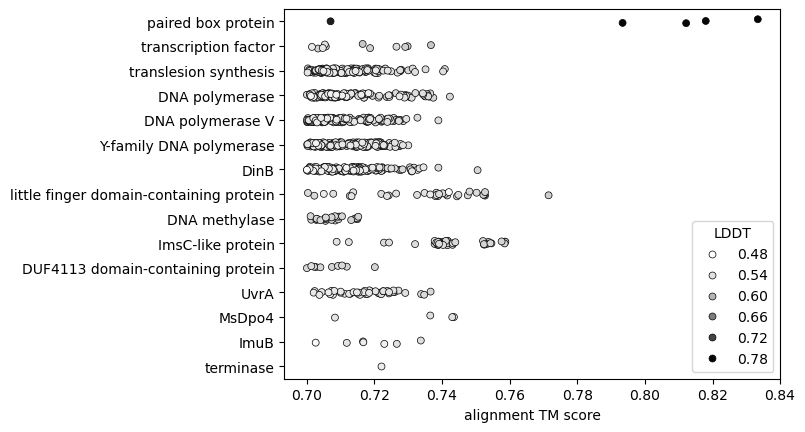

In [ ]:
fig, ax = plt.subplots()

figure_df = foldseek_search_df[~foldseek_search_df.category.isin(['none', 'uncharacterized', 'paired box protein'])].copy()
figure_df = figure_df.sort_values('lddt', ascending=False).drop_duplicates('target_id') # Keep the best hit to each target. 
sns.stripplot(figure_df, y='category', x='alignment_tm_score', ax=ax, hue='lddt', palette='Grays', edgecolor='black', linewidth=0.5)
ax.set_xlabel('alignment TM score')
ax.get_legend().set_title('LDDT')
ax.set_ylabel('')
plt.show()

In [42]:
foldseek_search_df[foldseek_search_df.query_start < 80][['target_header', 'target_start', 'target_end', 'target_length', 'alignment_tm_score', 'query_start', 'query_end']]

,target_header,target_start,target_end,target_length,alignment_tm_score,query_start,query_end
9782,6jus-assembly2_F MsDpo4-DNA complex 6,240,347,347,0.7329,76,205
9784,6jum-assembly2_F MsDpo4-DNA complex 2,240,347,347,0.7365,76,205
9785,6juo-assembly2_F MsDpo4-DNA complex 4,240,347,347,0.7339,76,205
9794,4irc-assembly1_F Polymerase-DNA complex,238,342,342,0.7182,77,200
9802,4r8u-assembly2_B S-SAD structure of DINB-DNA C...,235,338,338,0.7138,76,197
...,...,...,...,...,...,...,...
20988,AF-P0DA79-F1-model_v6 DNA polymerase IV,249,355,365,0.7184,77,200
20989,AF-P54560-F1-model_v6 DNA polymerase IV 2,244,357,412,0.7047,77,203
20997,AF-Q9K9A8-F1-model_v6 DNA polymerase IV 2,242,350,409,0.7280,77,199
21003,AF-A5D243-F1-model_v6 DNA polymerase IV,238,346,402,0.7068,76,200


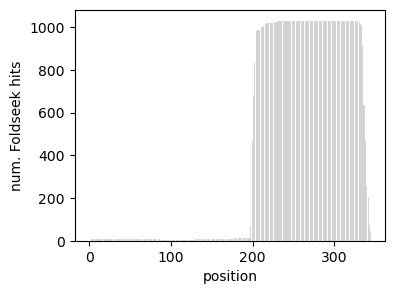

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))

figure_df = foldseek_search_df.copy()
figure_df = foldseek_search_df.drop_duplicates('target_id')
# Get the indices relative to the MSAFile. 
figure_df['msa_start'] = figure_df.apply(lambda row : msa.map_idx_to_msa(row.query_start, row.query_id), axis=1) 
figure_df['msa_stop'] = figure_df.apply(lambda row : msa.map_idx_to_msa(row.query_end, row.query_id), axis=1) 

positions = np.arange(msa.n_cols)
heights = np.zeros(len(positions))
for row in figure_df.itertuples():
    heights[np.arange(row.msa_start, row.msa_stop)] += 1 

ax.bar(positions, heights, color='lightgray', lw=0, edgecolor='black')
ax.set_ylabel('num. Foldseek hits')
ax.set_xlabel('position')
plt.show()
